# CS4045 - Deep Learning for Perception – CS(A)
# Assignment 2: CIFAR-10 Classification: ANN, CNN, and Hybrid Models

**Name:** Ahmed Murtaza Malik  
**Roll No.:** i22-0985  


---
## Assignment Outline

1. **ANN (Artificial Neural Network)**: Fully-connected feedforward network
2. **CNN (Convolutional Neural Network)**: Custom convolutional architecture
3. **Hybrid CNN+ANN**: CNN feature extractor with ANN classifier

**Target:** Achieve ≥70% test accuracy using custom architectures (no pretrained models)

**Dataset:** CIFAR-10 (50,000 training + 10,000 test images, 10 classes)

---

In [2]:
# IMPORTS
import os
import time
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns


import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# STYLES
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ All libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

✓ All libraries imported successfully
PyTorch version: 2.7.1+cu118
Torchvision version: 0.22.1+cu118


## 1. Setup 

In [3]:
# Random seeds and pytorch setup
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Use cuda if available else use CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✓ Using CUDA: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(f"Device: {device}")
print(f"Random Seed: {SEED}")

✓ Using CUDA: NVIDIA GeForce GTX 1060 3GB
Device: cuda
Random Seed: 42


In [4]:
# Helper Function Definitions

# Calculates the total and trainable parameter counts for a given model.
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable
    
# Generates and saves a side-by-side plot of training/validation loss and accuracy.
def plot_training_history(history, model_name="Model"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Loss curves
    ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
    ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title(f'{model_name} - Training & Validation Loss', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Accuracy curves
    ax2.plot(history['train_acc'], label='Train Accuracy', linewidth=2)
    ax2.plot(history['val_acc'], label='Val Accuracy', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title(f'{model_name} - Training & Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{model_name}_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved training curves to '{model_name}_training_curves.png'")
    
# Creates, displays, and saves a heatmap visualization of the confusion matrix.
def plot_confusion_matrix(y_true, y_pred, class_names, model_name="Model"):
    """Plot confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.title(f'{model_name} - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    save_path = f'{model_name}_confusion_matrix.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Confusion matrix visualization saved as '{save_path}'")

## 2. Dataset Preparation and Setup

In [5]:
# Define pre-calculated normalization statistics (Mean and Std) for CIFAR-10
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

# Transformation pipeline for the training dataset (includes augmentation)
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Transformation pipeline for validation and testing (normalization only)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Fetch or download the CIFAR-10 dataset
print("Loading CIFAR-10 data (will download if not found)...")
train_dataset_full = CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# Carve out a validation set from the full training data
train_size = 45000
val_size = 5000
train_dataset, val_dataset = random_split(
    train_dataset_full, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Ensure the validation set uses the standard 'test_transform' (no augmentation)
# We must re-assign the dataset object within the Subset to change its transform
val_dataset.dataset = CIFAR10(root='./data', train=True, download=False, transform=test_transform)

# Defining the list of class labels
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

print("\nDataset preparation finished.")
print(f"  Training images: {len(train_dataset):,}")
print(f"  Validation images: {len(val_dataset):,}")
print(f"  Test images: {len(test_dataset):,}")
print(f"  Total classes: {len(class_names)}")
print(f"  Class labels: {class_names}")

Loading CIFAR-10 data (will download if not found)...

Dataset preparation finished.
  Training images: 45,000
  Validation images: 5,000
  Test images: 10,000
  Total classes: 10
  Class labels: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
# DATA LOADERS
BATCH_SIZE = 512
NUM_WORKERS = 0

# Note: pinned memory is only beneficial for CUDA
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

print("Data loaders created")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of batches - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Data loaders created
Batch size: 512
Number of batches - Train: 88, Val: 10, Test: 20


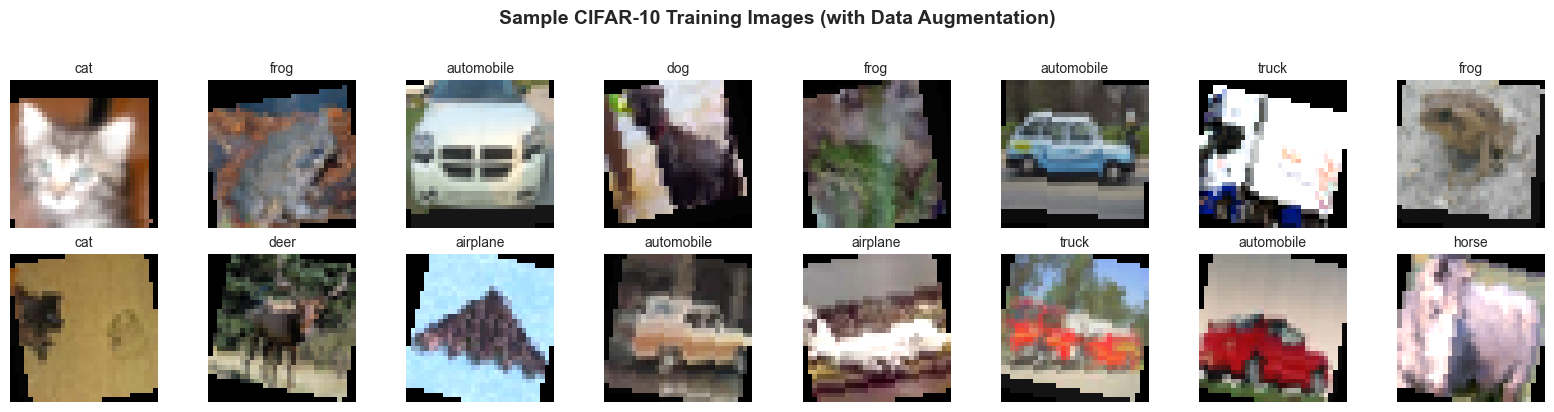

Example image batch has been displayed.


In [7]:
# VISUALIZATION OF A BATCH

# Fetch one batch of images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Reverses the normalization applied to a tensor for visual display.
def denormalize(tensor, mean, std):
    """Denormalize a tensor image."""
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

# Set up a grid for plotting
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

# Loop through the batch and display each image
for idx, ax in enumerate(axes.flat):
    # Ensure we don't try to plot more images than we have
    if idx < len(images):
        # We must clone the tensor, as denormalize works in-place
        img = denormalize(images[idx].clone(), CIFAR10_MEAN, CIFAR10_STD)

        # Change tensor format from (C, H, W) to (H, W, C) for matplotlib
        img = img.permute(1, 2, 0).numpy()

        # Ensure image data is within the valid [0, 1] range
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(class_names[labels[idx]], fontsize=10)
        ax.axis('off')

# Add an overall title to the figure
plt.suptitle('Sample CIFAR-10 Training Images (with Data Augmentation)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Example image batch has been displayed.")

## 3. Model Architectures Setup

### 3.1 ANN (Fully-Connected Network)

In [8]:
# Defines a simple Artificial Neural Network (ANN) using only fully-connected layers.
#
# Model Structure:
# 1. Flattens the input image (32x32x3 = 3072 features).
# 2. Passes data through a configurable stack of hidden layers.
# 3. Each hidden block consists of:
#    - nn.Linear
#    - nn.BatchNorm1d (optional)
#    - Activation (ReLU, GeLU, or Swish)
#    - nn.Dropout
# 4. A final linear classifier layer maps features to the number of classes.
#
# Parameters:
#   hidden_dims: A list specifying the size of each hidden layer.
#   dropout_rate: The dropout probability to apply after each hidden block.
#   activation: The name of the activation function ('relu', 'gelu', 'swish').
#   use_batchnorm: Boolean flag to include BatchNorm1d layers.
#   num_classes: The number of output neurons (e.g., 10 for CIFAR-10).

class ANN(nn.Module):
    def __init__(self, hidden_dims=[2048, 1024, 512, 256], dropout_rate=0.5, 
                 activation='relu', use_batchnorm=True, num_classes=10):
        super().__init__()
        
        # Choose activation function
        if activation == 'relu':
            self.activation = nn.ReLU(inplace=True)
        elif activation == 'gelu':
            self.activation = nn.GELU()
        elif activation == 'swish':
            self.activation = nn.SiLU()  # SiLU is the same as Swish
        else:
            self.activation = nn.ReLU(inplace=True)
        
        layers = []
        in_features = 3072  # 32*32*3 (flattened CIFAR-10 image)
        
        for hidden_dim in hidden_dims:
            # Linear layer
            layers.append(nn.Linear(in_features, hidden_dim))
            
            # Batch normalization
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            
            # Activation
            layers.append(self.activation)
            
            # Dropout
            layers.append(nn.Dropout(dropout_rate))
            
            in_features = hidden_dim
        
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Linear(in_features, num_classes)
        
    def forward(self, x):
        # Flatten input: (batch_size, 3, 32, 32) -> (batch_size, 3072)
        x = x.view(x.size(0), -1)
        # Feature extraction through hidden layers
        x = self.features(x)
        # Classification
        x = self.classifier(x)
        return x

# Create ANN model
ann_model = ANN(
    hidden_dims=[2048, 1024, 512, 256],
    dropout_rate=0.5,
    activation='relu',
    use_batchnorm=True,
    num_classes=10
).to(device)

total_params, trainable_params = count_parameters(ann_model)
print("="*80)
print("ANN MODEL ARCHITECTURE")
print("="*80)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: {total_params * 4 / (1024**2):.2f} MB (float32)")
print("="*80)

ANN MODEL ARCHITECTURE
Total parameters: 9,058,058
Trainable parameters: 9,058,058
Model size: 34.55 MB (float32)


### 3.2 CNN (Convolutional Neural Network)

In [9]:
# Defines a custom-built Convolutional Neural Network (CNN).
#
# Model Structure:
# - Stacks multiple convolutional blocks, with filter depth increasing progressively.
# - Each standard block follows the pattern:
#   (Conv2d -> BatchNorm -> Activation -> Conv2d -> BatchNorm -> Activation -> MaxPool2d)
# - After the feature extraction blocks, a fully-connected (dense) classifier
#   head, including dropout, maps the features to the final class predictions.
#
# Class Arguments:
#   base_filters: The starting number of filters in the first conv layer.
#   num_blocks: The total number of (Conv-Conv-Pool) blocks to stack.
#   dropout_rate: The probability of dropout in the final classifier.
#   activation: String name of the activation function ('relu', 'gelu', 'swish').
#   num_classes: The number of output neurons for classification.

class CNN(nn.Module):
    def __init__(self, base_filters=64, num_blocks=3, dropout_rate=0.5,
                 activation='relu', num_classes=10):
        super().__init__()
        
        self.activation_type = activation
        
        conv_layers = []
        in_channels = 3
        filters = base_filters
        
        for i in range(num_blocks):
            # First conv in block
            conv_layers.append(nn.Conv2d(in_channels, filters, kernel_size=3, padding=1))
            conv_layers.append(nn.BatchNorm2d(filters))
            conv_layers.append(self._get_activation())
            
            # Second conv in block
            conv_layers.append(nn.Conv2d(filters, filters, kernel_size=3, padding=1))
            conv_layers.append(nn.BatchNorm2d(filters))
            conv_layers.append(self._get_activation())
            
            # MaxPooling
            conv_layers.append(nn.MaxPool2d(2, 2))
            
            in_channels = filters
            filters = filters * 2  # Double filters for next block
        
        self.conv_features = nn.Sequential(*conv_layers)
        
        # Calculate flattened size
        # After num_blocks pooling layers: 32 -> 16 -> 8 -> 4 -> ...
        final_spatial_size = 32 // (2 ** num_blocks)
        final_filters = base_filters * (2 ** (num_blocks - 1))
        flattened_size = final_filters * final_spatial_size * final_spatial_size
        
        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(flattened_size, 512),
            nn.BatchNorm1d(512),
            self._get_activation(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_classes)
        )
    
    def _get_activation(self):
        """Create a new activation function instance."""
        if self.activation_type == 'relu':
            return nn.ReLU(inplace=True)
        elif self.activation_type == 'gelu':
            return nn.GELU()
        elif self.activation_type == 'swish':
            return nn.SiLU()
        else:
            return nn.ReLU(inplace=True)
        
    def forward(self, x):
        x = self.conv_features(x)
        x = self.classifier(x)
        return x

# Create CNN model
cnn_model = CNN(
    base_filters=64,
    num_blocks=3,
    dropout_rate=0.5,
    activation='relu',
    num_classes=10
).to(device)

total_params, trainable_params = count_parameters(cnn_model)
print("="*80)
print("CNN MODEL ARCHITECTURE")
print("="*80)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: {total_params * 4 / (1024**2):.2f} MB (float32)")
print("="*80)

CNN MODEL ARCHITECTURE
Total parameters: 3,251,018
Trainable parameters: 3,251,018
Model size: 12.40 MB (float32)


### 3.3 Hybrid CNN+ANN Model

In [10]:
# Implements a hybrid model using a CNN for feature extraction and an ANN for classification.
#
# This architecture leverages the spatial-learning capabilities of a CNN
# to first process the input image into a flat feature vector. This vector
# is then passed to a separate, multi-layer fully-connected network (ANN)
# which performs the final classification.
#
# Model Structure:
# 1. CNN Feature Extractor: A series of convolutional blocks.
# 2. Flatten Layer: Converts the 2D feature map into a 1D vector.
# 3. ANN Classifier Head: A stack of dense (Linear) layers.
#
# Class Arguments:
#   cnn_filters: A list defining the filter counts for each CNN block (e.g., [64, 128]).
#   ann_hidden_dims: A list specifying the neuron counts for the ANN's hidden layers.
#   dropout_rate: The dropout probability to be used.
#   activation: The string name of the activation function.
#   num_classes: The final number of output classes.

class HybridCNNANN(nn.Module):
    def __init__(self, cnn_filters=[64, 128, 256], ann_hidden_dims=[512, 256],
                 dropout_rate=0.5, activation='relu', num_classes=10):
        super().__init__()
        
        self.activation_type = activation
        
        # CNN Feature Extractor
        cnn_layers = []
        in_channels = 3
        
        for filters in cnn_filters:
            # Conv block: Conv -> BN -> Activation -> Conv -> BN -> Activation -> MaxPool
            cnn_layers.append(nn.Conv2d(in_channels, filters, kernel_size=3, padding=1))
            cnn_layers.append(nn.BatchNorm2d(filters))
            cnn_layers.append(self._get_activation())
            cnn_layers.append(nn.Conv2d(filters, filters, kernel_size=3, padding=1))
            cnn_layers.append(nn.BatchNorm2d(filters))
            cnn_layers.append(self._get_activation())
            cnn_layers.append(nn.MaxPool2d(2, 2))
            in_channels = filters
        
        self.cnn_extractor = nn.Sequential(*cnn_layers)
        
        # Calculate CNN output size
        # After len(cnn_filters) pooling layers: 32 -> 16 -> 8 -> 4
        final_spatial_size = 32 // (2 ** len(cnn_filters))
        cnn_output_size = cnn_filters[-1] * final_spatial_size * final_spatial_size
        
        # ANN Classifier
        ann_layers = []
        ann_layers.append(nn.Flatten())
        
        in_features = cnn_output_size
        for hidden_dim in ann_hidden_dims:
            ann_layers.append(nn.Linear(in_features, hidden_dim))
            ann_layers.append(nn.BatchNorm1d(hidden_dim))
            ann_layers.append(self._get_activation())
            ann_layers.append(nn.Dropout(dropout_rate))
            in_features = hidden_dim
        
        ann_layers.append(nn.Linear(in_features, num_classes))
        
        self.ann_classifier = nn.Sequential(*ann_layers)
    
    def _get_activation(self):
        """Create a new activation function instance."""
        if self.activation_type == 'relu':
            return nn.ReLU(inplace=True)
        elif self.activation_type == 'gelu':
            return nn.GELU()
        elif self.activation_type == 'swish':
            return nn.SiLU()
        else:
            return nn.ReLU(inplace=True)
        
    def forward(self, x):
        # CNN feature extraction
        x = self.cnn_extractor(x)
        # ANN classification
        x = self.ann_classifier(x)
        return x

# Create Hybrid model
hybrid_model = HybridCNNANN(
    cnn_filters=[64, 128, 256],
    ann_hidden_dims=[512, 256],
    dropout_rate=0.5,
    activation='relu',
    num_classes=10
).to(device)

total_params, trainable_params = count_parameters(hybrid_model)
print("="*80)
print("HYBRID CNN+ANN MODEL ARCHITECTURE")
print("="*80)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: {total_params * 4 / (1024**2):.2f} MB (float32)")
print("="*80)

HYBRID CNN+ANN MODEL ARCHITECTURE
Total parameters: 3,380,298
Trainable parameters: 3,380,298
Model size: 12.89 MB (float32)


## 4. Training & Evaluation Functions Setup

In [11]:
# Handles the complete training loop for a given model.
#
# This function incorporates:
# - Standard training and validation steps per epoch.
# - Optional learning rate scheduling (Cosine Annealing).
# - Early stopping to halt training if validation loss doesn't improve.
# - Saving the best model checkpoint based on validation performance.
#
# Parameters:
#   model: The PyTorch model instance to be trained.
#   train_loader: DataLoader for the training dataset.
#   val_loader: DataLoader for the validation dataset.
#   epochs: The maximum number of training epochs.
#   lr: The starting learning rate for the optimizer.
#   weight_decay: The L2 penalty (weight decay) value.
#   device: The 'cuda' or 'cpu' device to use.
#   model_name: A string name used for saving the best model file.
#   use_scheduler: If True, applies a cosine annealing LR scheduler.
#   patience: Number of epochs to wait for improvement before stopping early.
#
# Returns:
#   A tuple containing:
#   - model: The model loaded with the best performing weights.
#   - history: A dictionary tracking train/val loss and accuracy per epoch.
#   - training_time: The total time taken for the training loop (in seconds).

def train_model(model, train_loader, val_loader, epochs=50, lr=0.001, 
                weight_decay=1e-4, device='cpu', model_name="Model",
                use_scheduler=True, patience=10):
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    if use_scheduler:
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_val_acc = 0.0
    epochs_no_improve = 0
    start_time = time.time()
    
    print(f"\n{'='*80}")
    print(f"Training {model_name}")
    print(f"{'='*80}")
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', leave=False)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        # Calculate metrics
        train_loss /= len(train_loader)
        train_acc = train_correct / train_total
        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Print epoch summary
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        # Learning rate scheduling
        if use_scheduler:
            scheduler.step()
        
        # Early stopping and model checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), f'{model_name}_best.pth')
            print(f"  ✓ New best model saved! Val Acc: {val_acc:.4f}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\n  Early stopping triggered after {epoch+1} epochs")
                break
    
    training_time = time.time() - start_time
    
    # Load best model
    model.load_state_dict(torch.load(f'{model_name}_best.pth'))
    
    print(f"\n{'='*80}")
    print(f"{model_name} Training Complete!")
    print(f"Best Validation Accuracy: {best_val_acc:.4f}")
    print(f"Total Training Time: {training_time/60:.2f} minutes")
    print(f"{'='*80}\n")
    
    return model, history, training_time

In [12]:
# Evaluates the performance of a trained model on the test dataset.
#
# Runs the model in evaluation mode (no gradients) over the entire
# test set to calculate final accuracy and gather all predictions.
#
# Parameters:
#   model: The trained PyTorch model to evaluate.
#   test_loader: DataLoader for the test dataset.
#   device: The 'cuda' or 'cpu' device to use for evaluation.
#
# Returns:
#   A tuple containing:
#   - accuracy: The final test accuracy (float).
#   - predictions: A list of the model's output predictions for each sample.
#   - true_labels: A list of the corresponding ground truth labels.

def evaluate_model(model, test_loader, device='cpu'):
    model.eval()
    model = model.to(device)
    
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc='Evaluating'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    accuracy = accuracy_score(all_labels, all_predictions)
    
    return accuracy, np.array(all_predictions), np.array(all_labels)

## 5. Training of All 3 Models

### 5.1 ANN Model Training


Training ANN


Epoch 1/50:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 1/50 | Train Loss: 2.0614 | Train Acc: 0.2368 | Val Loss: 1.8084 | Val Acc: 0.3358 | LR: 0.001000
  ✓ New best model saved! Val Acc: 0.3358


Epoch 2/50:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 2/50 | Train Loss: 1.8715 | Train Acc: 0.3142 | Val Loss: 1.6976 | Val Acc: 0.3842 | LR: 0.000999
  ✓ New best model saved! Val Acc: 0.3842


...

Epoch 48/50 | Train Loss: 1.4069 | Train Acc: 0.4978 | Val Loss: 1.2379 | Val Acc: 0.5640 | LR: 0.000010


Epoch 49/50:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 49/50 | Train Loss: 1.4039 | Train Acc: 0.4958 | Val Loss: 1.2363 | Val Acc: 0.5656 | LR: 0.000005
  ✓ New best model saved! Val Acc: 0.5656


Epoch 50/50:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 50/50 | Train Loss: 1.4111 | Train Acc: 0.4933 | Val Loss: 1.2389 | Val Acc: 0.5620 | LR: 0.000002

ANN Training Complete!
Best Validation Accuracy: 0.5656
Total Training Time: 30.29 minutes



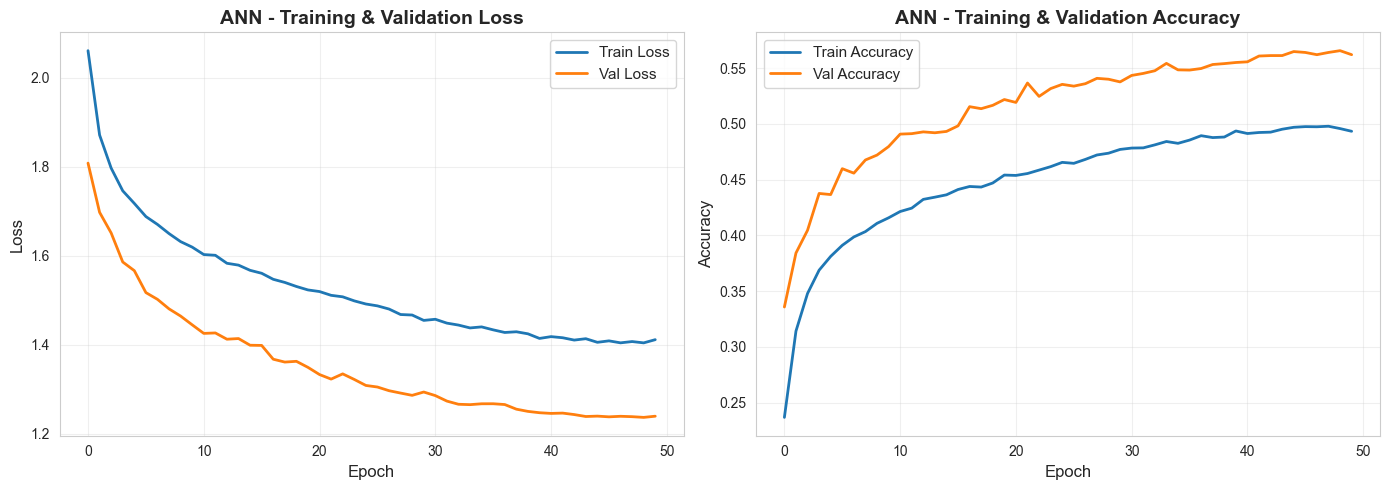

✓ Saved training curves to 'ANN_training_curves.png'


In [13]:
# Train ANN Model
ann_model = ANN(
    hidden_dims=[2048, 1024, 512, 256],
    dropout_rate=0.5,
    activation='relu',
    use_batchnorm=True
).to(device)

ann_trained, ann_history, ann_time = train_model(
    model=ann_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    lr=0.001,
    weight_decay=1e-4,
    device=device,
    model_name="ANN",
    use_scheduler=True,
    patience=10
)

# Plot training history
plot_training_history(ann_history, "ANN")

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]


ANN TEST RESULTS
Test Accuracy: 0.5593 (55.93%)



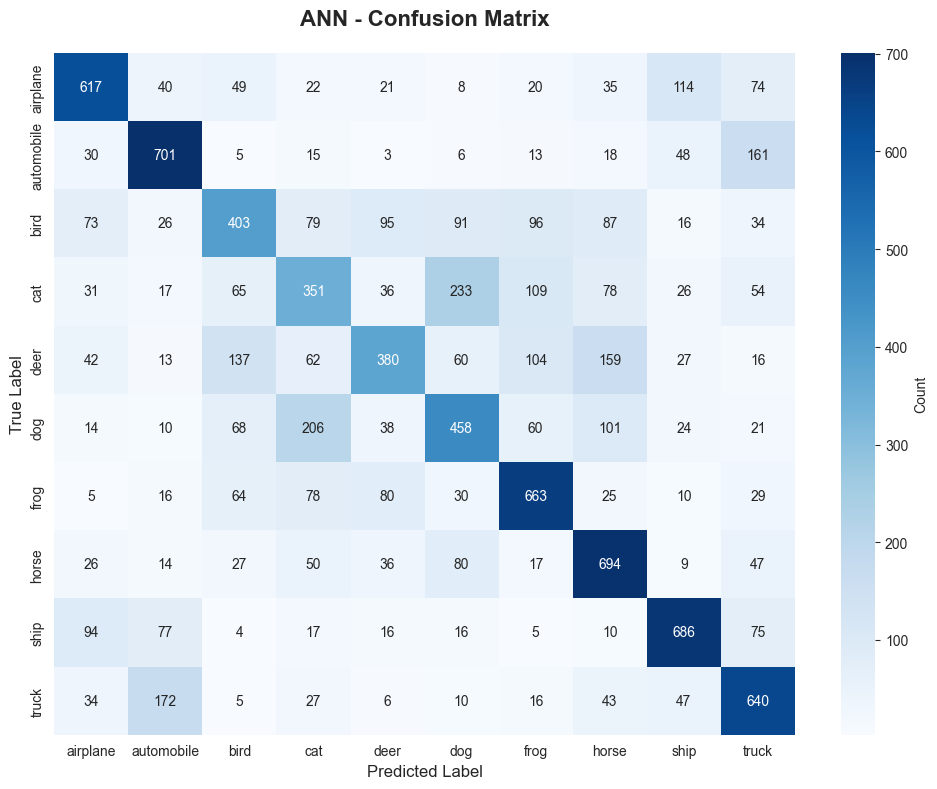

Confusion matrix visualization saved as 'ANN_confusion_matrix.png'


In [14]:
# Evaluate ANN on Test Set
ann_acc, ann_preds, ann_labels = evaluate_model(ann_trained, test_loader, device)

print(f"\n{'='*80}")
print(f"ANN TEST RESULTS")
print(f"{'='*80}")
print(f"Test Accuracy: {ann_acc:.4f} ({ann_acc*100:.2f}%)")
print(f"{'='*80}\n")

# Plot confusion matrix
plot_confusion_matrix(ann_labels, ann_preds, class_names, "ANN")

### 5.2 Train CNN Model


Training CNN


Epoch 1/50:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 1/50 | Train Loss: 1.5714 | Train Acc: 0.4227 | Val Loss: 1.1630 | Val Acc: 0.5804 | LR: 0.001000
  ✓ New best model saved! Val Acc: 0.5804


Epoch 2/50:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 2/50 | Train Loss: 1.1700 | Train Acc: 0.5774 | Val Loss: 1.1320 | Val Acc: 0.5888 | LR: 0.000999
  ✓ New best model saved! Val Acc: 0.5888


...

Epoch 48/50 | Train Loss: 0.1934 | Train Acc: 0.9330 | Val Loss: 0.2584 | Val Acc: 0.9136 | LR: 0.000010


Epoch 49/50:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 49/50 | Train Loss: 0.1936 | Train Acc: 0.9328 | Val Loss: 0.2586 | Val Acc: 0.9144 | LR: 0.000005


Epoch 50/50:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 50/50 | Train Loss: 0.1918 | Train Acc: 0.9321 | Val Loss: 0.2583 | Val Acc: 0.9142 | LR: 0.000002

CNN Training Complete!
Best Validation Accuracy: 0.9144
Total Training Time: 39.13 minutes



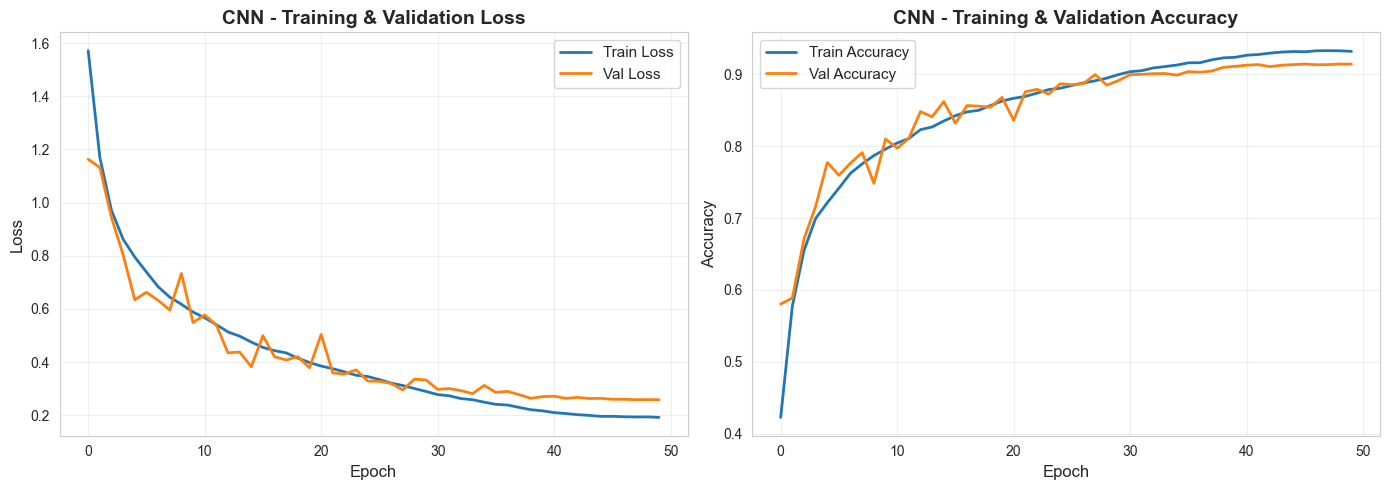

✓ Saved training curves to 'CNN_training_curves.png'


In [15]:
# Train CNN Model
cnn_model = CNN(
    base_filters=64,
    num_blocks=3,
    dropout_rate=0.5,
    activation='relu'
).to(device)

cnn_trained, cnn_history, cnn_time = train_model(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    lr=0.001,
    weight_decay=1e-4,
    device=device,
    model_name="CNN",
    use_scheduler=True,
    patience=10
)

# Plot training history
plot_training_history(cnn_history, "CNN")

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]


CNN TEST RESULTS
Test Accuracy: 0.9084 (90.84%)



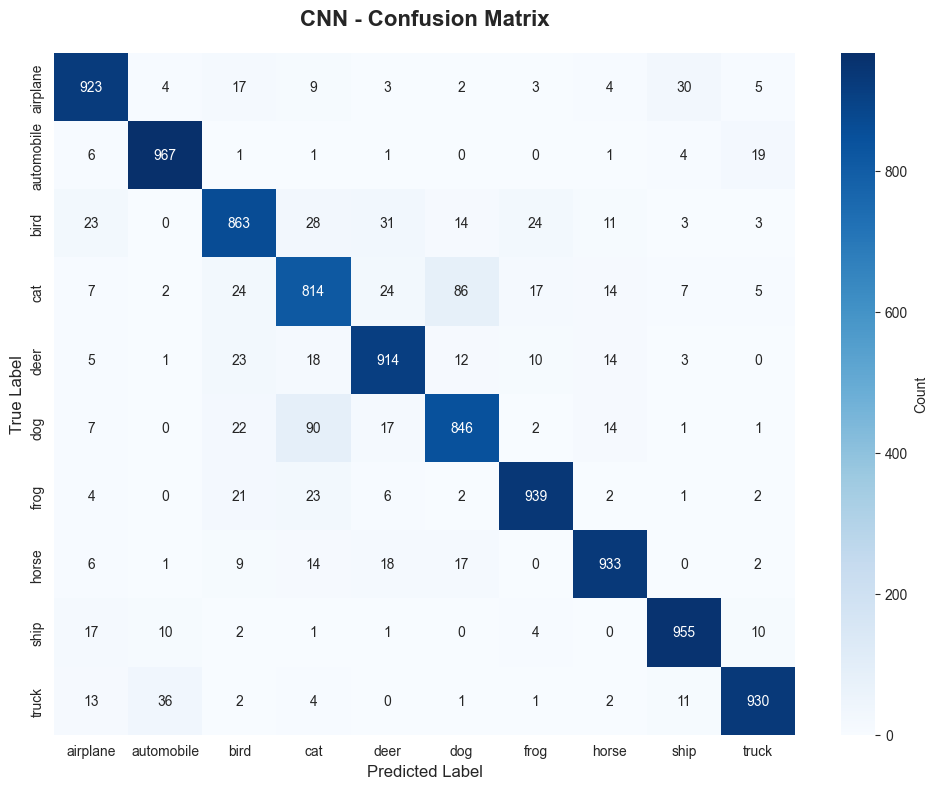

Confusion matrix visualization saved as 'CNN_confusion_matrix.png'


In [16]:
# Evaluate CNN on Test Set
cnn_acc, cnn_preds, cnn_labels = evaluate_model(cnn_trained, test_loader, device)

print(f"\n{'='*80}")
print(f"CNN TEST RESULTS")
print(f"{'='*80}")
print(f"Test Accuracy: {cnn_acc:.4f} ({cnn_acc*100:.2f}%)")
print(f"{'='*80}\n")

# Plot confusion matrix
plot_confusion_matrix(cnn_labels, cnn_preds, class_names, "CNN")

### 5.3 Train Hybrid CNN+ANN Model


Training Hybrid


Epoch 1/50:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 1/50 | Train Loss: 1.6172 | Train Acc: 0.4075 | Val Loss: 1.4337 | Val Acc: 0.4856 | LR: 0.001000
  ✓ New best model saved! Val Acc: 0.4856


Epoch 2/50:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 2/50 | Train Loss: 1.2066 | Train Acc: 0.5687 | Val Loss: 0.9612 | Val Acc: 0.6532 | LR: 0.000999
  ✓ New best model saved! Val Acc: 0.6532


...

Epoch 48/50 | Train Loss: 0.1511 | Train Acc: 0.9493 | Val Loss: 0.2744 | Val Acc: 0.9166 | LR: 0.000010


Epoch 49/50:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 49/50 | Train Loss: 0.1453 | Train Acc: 0.9511 | Val Loss: 0.2744 | Val Acc: 0.9166 | LR: 0.000005


Epoch 50/50:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 50/50 | Train Loss: 0.1462 | Train Acc: 0.9498 | Val Loss: 0.2748 | Val Acc: 0.9172 | LR: 0.000002

Hybrid Training Complete!
Best Validation Accuracy: 0.9184
Total Training Time: 39.19 minutes



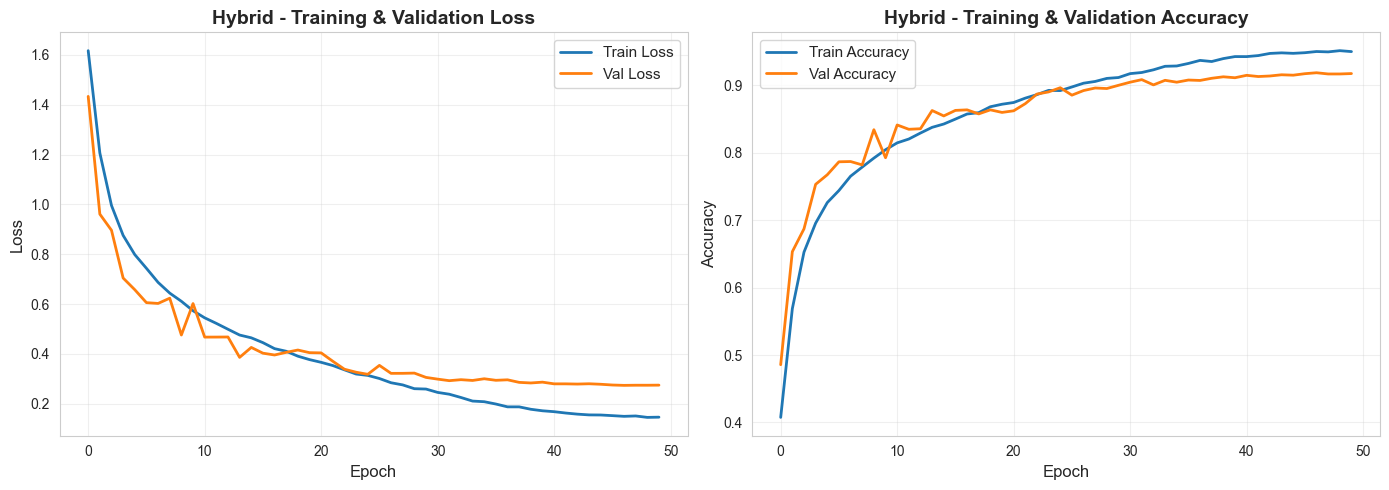

✓ Saved training curves to 'Hybrid_training_curves.png'


In [17]:
# Train Hybrid Model
hybrid_model = HybridCNNANN(
    cnn_filters=[64, 128, 256],
    ann_hidden_dims=[512, 256],
    dropout_rate=0.5,
    activation='relu'
).to(device)

hybrid_trained, hybrid_history, hybrid_time = train_model(
    model=hybrid_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    lr=0.001,
    weight_decay=1e-4,
    device=device,
    model_name="Hybrid",
    use_scheduler=True,
    patience=10
)

# Plot training history
plot_training_history(hybrid_history, "Hybrid")

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]


HYBRID CNN+ANN TEST RESULTS
Test Accuracy: 0.9113 (91.13%)



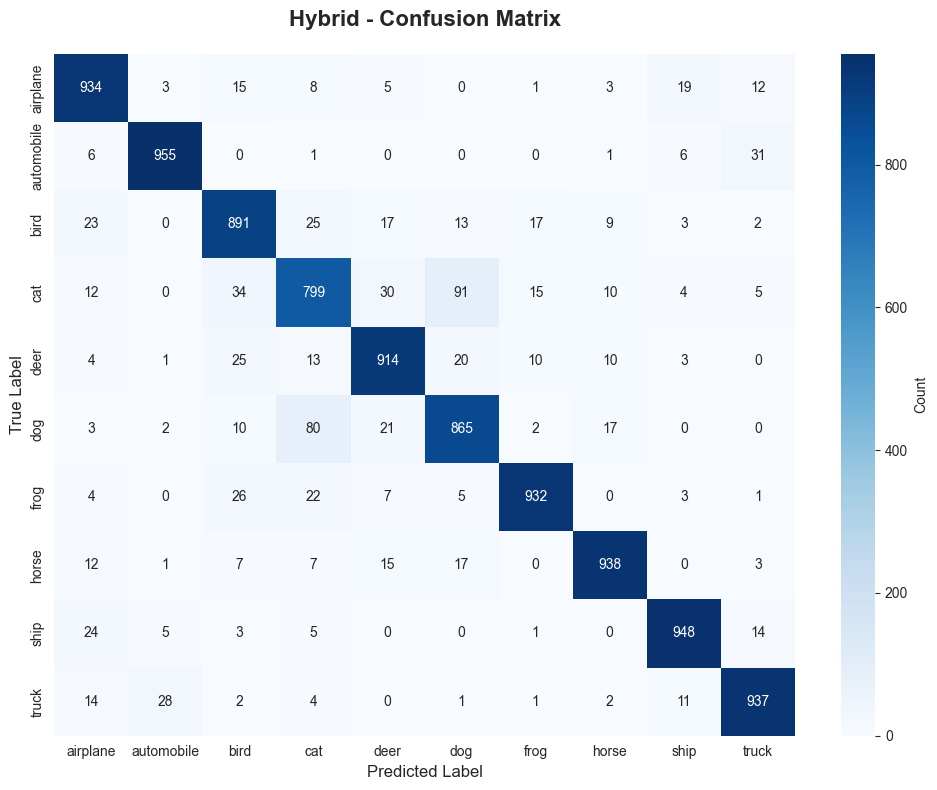

Confusion matrix visualization saved as 'Hybrid_confusion_matrix.png'


In [18]:
# Evaluate Hybrid on Test Set
hybrid_acc, hybrid_preds, hybrid_labels = evaluate_model(hybrid_trained, test_loader, device)

print(f"\n{'='*80}")
print(f"HYBRID CNN+ANN TEST RESULTS")
print(f"{'='*80}")
print(f"Test Accuracy: {hybrid_acc:.4f} ({hybrid_acc*100:.2f}%)")
print(f"{'='*80}\n")

# Plot confusion matrix
plot_confusion_matrix(hybrid_labels, hybrid_preds, class_names, "Hybrid")

## 6. Ablation Studies

A series of focused experiments to isolate and understand the contribution of individual model design choices.

### Components of Investigation:

**1. Activation Functions** 
- Comparison: ReLU vs. GELU vs. Swish (SiLU).
- Objective: Assess impact on training speed and final accuracy

**2. Dropout Regularization**
- Rates Tested: 0.0 (none), 0.3, 0.5, 0.7.
- Objective: Find the optimal trade-off between under-fitting and over-fitting.

**3. Learning Rate Magnitude** 
- Rates Tested: 1e-4, 1e-3, 1e-2.
- Objective: Evaluate effect on training stability and convergence speed.

**4. ANN Topology** 
- Comparison: Deeper, narrow networks vs. wider, shallow networks.
- Objective: Analyze the trade-offs between network depth and width.

**5. Normalization Layers** 
- Comparison: Using BatchNorm vs. no normalization.
- Objective: Measure the impact on training stability and convergence.

**6. Optimization Algorithms** 
- Algorithms: Adam, AdamW, and SGD (with momentum).
- Objective: Compare convergence behavior and performance.

**7. LR Scheduling Strategies** 
- Strategies: Constant LR vs. Step Decay vs. Cosine Annealing.
- Objective: Determine the effect of LR scheduling on final model quality.

**8. Additional Regularizers** 
- Techniques: Label Smoothing (at 0.1) and Gradient Clipping (at 1.0).
- Objective: Evaluate their independent and combined effects on generalization.

**9. CNN Architectural Choices**
- Variables: Network depth (2, 3, or 4 blocks) and base filter count (32, 64, or 128).
- Objective: Study the relationship between model capacity and performance.

Total Configurations Tested: Over 25 distinct setups.

To ensure efficient yet thorough analysis, each experimental run was limited to 20 epochs, utilizing early stopping with a patience of 8 epochs. In every experiment, only the variable under investigation was modified; all other hyperparameters were held constant to guarantee a fair comparison.

In [20]:
# Executes one complete ablation experiment for a specific model configuration.
#
# This function serves as a wrapper to:
# 1. Instantiate a fresh model using the provided 'model_class' and 'model_kwargs'.
# 2. Train the model using the 'train_kwargs'.
# 3. Print a summary header for the experiment using 'config_name' and 'description'.
#
# Parameters:
#   model_class: The model class to be instantiated (e.g., ANN, CustomCNN).
#   config_name: A short, unique name for this experimental run (e.g., "ANN_GELU").
#   model_kwargs: A dictionary of arguments for the model's constructor.
#   train_kwargs: A dictionary of arguments for the main 'train' function.
#   description: A human-readable summary of what this experiment is testing.

ablation_results = []

def run_ablation(model_class, config_name, model_kwargs, train_kwargs, description=""):
    print(f"\n{'='*80}")
    print(f"ABLATION: {config_name}")
    print(f"Description: {description}")
    print(f"{'='*80}")
    
    model = model_class(**model_kwargs).to(device)
    total_params, _ = count_parameters(model)
    
    trained_model, history, train_time = train_model(model, **train_kwargs)
    test_acc, _, _ = evaluate_model(trained_model, test_loader, device)
    
    best_val_acc = max(history['val_acc'])
    
    ablation_results.append({
        'Configuration': config_name,
        'Description': description,
        'Val Accuracy': f"{best_val_acc:.4f}",
        'Test Accuracy': f"{test_acc:.4f}",
        'Parameters': f"{total_params:,}",
        'Time (min)': f"{train_time/60:.2f}"
    })
    
    print(f"\n✓ {config_name} Complete | Val: {best_val_acc:.4f} | Test: {test_acc:.4f}")
    
    return test_acc, best_val_acc

print("Ablation function defined")

Ablation function defined


### Activation Function 

In [21]:
# Test ReLU activation (baseline)
run_ablation(
    model_class=CNN,
    config_name="CNN_ReLU",
    model_kwargs={'base_filters': 64, 'num_blocks': 3, 'dropout_rate': 0.5, 'activation': 'relu'},
    train_kwargs={'train_loader': train_loader, 'val_loader': val_loader, 'epochs': 20, 
                  'lr': 0.001, 'weight_decay': 1e-4, 'device': device, 'model_name': 'CNN_ReLU',
                  'use_scheduler': True, 'patience': 8},
    description="CNN with ReLU activation"
)

# Test GELU activation
run_ablation(
    model_class=CNN,
    config_name="CNN_GELU",
    model_kwargs={'base_filters': 64, 'num_blocks': 3, 'dropout_rate': 0.5, 'activation': 'gelu'},
    train_kwargs={'train_loader': train_loader, 'val_loader': val_loader, 'epochs': 20,
                  'lr': 0.001, 'weight_decay': 1e-4, 'device': device, 'model_name': 'CNN_GELU',
                  'use_scheduler': True, 'patience': 8},
    description="CNN with GELU activation"
)

# Test Swish activation
run_ablation(
    model_class=CNN,
    config_name="CNN_Swish",
    model_kwargs={'base_filters': 64, 'num_blocks': 3, 'dropout_rate': 0.5, 'activation': 'swish'},
    train_kwargs={'train_loader': train_loader, 'val_loader': val_loader, 'epochs': 20,
                  'lr': 0.001, 'weight_decay': 1e-4, 'device': device, 'model_name': 'CNN_Swish',
                  'use_scheduler': True, 'patience': 8},
    description="CNN with Swish (SiLU) activation"
)


ABLATION: CNN_ReLU
Description: CNN with ReLU activation

Training CNN_ReLU


Epoch 1/20:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 1/20 | Train Loss: 1.5483 | Train Acc: 0.4288 | Val Loss: 1.2539 | Val Acc: 0.5640 | LR: 0.001000
  ✓ New best model saved! Val Acc: 0.5640


Epoch 2/20:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 2/20 | Train Loss: 1.1576 | Train Acc: 0.5843 | Val Loss: 1.0943 | Val Acc: 0.6232 | LR: 0.000994
  ✓ New best model saved! Val Acc: 0.6232


...

Epoch 20/20:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.3772 | Train Acc: 0.8704 | Val Loss: 0.3379 | Val Acc: 0.8812 | LR: 0.000007
  ✓ New best model saved! Val Acc: 0.8812

CNN_Swish Training Complete!
Best Validation Accuracy: 0.8812
Total Training Time: 30.55 minutes



Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]


✓ CNN_Swish Complete | Val: 0.8812 | Test: 0.8729


(0.8729, 0.8812)

### Dropout Regularization

In [22]:
# No dropout
run_ablation(
    model_class=ANN,
    config_name="ANN_NoDropout",
    model_kwargs={'hidden_dims': [2048, 1024, 512, 256], 'dropout_rate': 0.0, 'activation': 'relu'},
    train_kwargs={'train_loader': train_loader, 'val_loader': val_loader, 'epochs': 20,
                  'lr': 0.001, 'weight_decay': 1e-4, 'device': device, 'model_name': 'ANN_NoDropout',
                  'use_scheduler': True, 'patience': 8},
    description="ANN without dropout (expect overfitting)"
)

# Light dropout (0.3)
run_ablation(
    model_class=ANN,
    config_name="ANN_Dropout03",
    model_kwargs={'hidden_dims': [2048, 1024, 512, 256], 'dropout_rate': 0.3, 'activation': 'relu'},
    train_kwargs={'train_loader': train_loader, 'val_loader': val_loader, 'epochs': 20,
                  'lr': 0.001, 'weight_decay': 1e-4, 'device': device, 'model_name': 'ANN_Dropout03',
                  'use_scheduler': True, 'patience': 8},
    description="ANN with dropout=0.3"
)

# Heavy dropout (0.7)
run_ablation(
    model_class=ANN,
    config_name="ANN_Dropout07",
    model_kwargs={'hidden_dims': [2048, 1024, 512, 256], 'dropout_rate': 0.7, 'activation': 'relu'},
    train_kwargs={'train_loader': train_loader, 'val_loader': val_loader, 'epochs': 20,
                  'lr': 0.001, 'weight_decay': 1e-4, 'device': device, 'model_name': 'ANN_Dropout07',
                  'use_scheduler': True, 'patience': 8},
    description="ANN with dropout=0.7"
)


ABLATION: ANN_NoDropout
Description: ANN without dropout (expect overfitting)

Training ANN_NoDropout


Epoch 1/20:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 1/20 | Train Loss: 1.8460 | Train Acc: 0.3258 | Val Loss: 1.7065 | Val Acc: 0.3822 | LR: 0.001000
  ✓ New best model saved! Val Acc: 0.3822


Epoch 2/20:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 2/20 | Train Loss: 1.6680 | Train Acc: 0.3952 | Val Loss: 1.5449 | Val Acc: 0.4394 | LR: 0.000994
  ✓ New best model saved! Val Acc: 0.4394


...

Epoch 20/20:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 1.6969 | Train Acc: 0.3847 | Val Loss: 1.5161 | Val Acc: 0.4530 | LR: 0.000007

ANN_Dropout07 Training Complete!
Best Validation Accuracy: 0.4532
Total Training Time: 10.90 minutes



Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]


✓ ANN_Dropout07 Complete | Val: 0.4532 | Test: 0.4559


(0.4559, 0.4532)

### Optimization Algorithms (Helper)

In [23]:
# Executes an advanced training loop with configurable optimizers and schedulers.
#
# This function expands on the standard training loop by allowing
# dynamic selection of optimizers, learning rate schedulers, and
# advanced regularization techniques like label smoothing and gradient clipping.
#
# Parameters:
#   optimizer_type: String name of the optimizer ('sgd', 'adam', 'adamw').
#   scheduler_type: String name of the LR scheduler ('cosine', 'step', or None).
#   label_smoothing: The factor for label smoothing (0.0 means no smoothing).
#   grad_clip: The maximum norm value for gradient clipping (set to None to disable).

# Helper function for advanced training with more options
def train_model_advanced(model, train_loader, val_loader, epochs=20, lr=0.001,
                        weight_decay=1e-4, device='cpu', model_name="Model",
                        optimizer_type='adamw', scheduler_type='cosine',
                        label_smoothing=0.0, grad_clip=None, patience=8):
    model = model.to(device)
    
    # Choose optimizer
    if optimizer_type == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_type == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:  # adamw
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Choose scheduler
    if scheduler_type == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    elif scheduler_type == 'step':
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    else:
        scheduler = None
    
    # Loss with optional label smoothing
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    epochs_no_improve = 0
    start_time = time.time()
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Gradient clipping
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        train_loss /= len(train_loader)
        train_acc = train_correct / train_total
        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if scheduler is not None:
            scheduler.step()
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), f'{model_name}_best.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break
    
    training_time = time.time() - start_time
    model.load_state_dict(torch.load(f'{model_name}_best.pth'))
    
    return model, history, training_time

print("Advanced training function defined")

Advanced training function defined


### ANN Topology

In [24]:
# Wide vs Deep Networks

# Shallow & Wide (2 layers, large width)
run_ablation(
    model_class=ANN,
    config_name="ANN_Wide_Shallow",
    model_kwargs={'hidden_dims': [4096, 2048], 'dropout_rate': 0.5, 'activation': 'relu'},
    train_kwargs={'train_loader': train_loader, 'val_loader': val_loader, 'epochs': 20,
                  'lr': 0.001, 'weight_decay': 1e-4, 'device': device, 'model_name': 'ANN_Wide_Shallow',
                  'use_scheduler': True, 'patience': 8},
    description="Wide & shallow ANN (2 layers, 4096→2048)"
)

# Deep & Narrow (6 layers, small width)
run_ablation(
    model_class=ANN,
    config_name="ANN_Narrow_Deep",
    model_kwargs={'hidden_dims': [1024, 512, 512, 256, 256, 128], 'dropout_rate': 0.5, 'activation': 'relu'},
    train_kwargs={'train_loader': train_loader, 'val_loader': val_loader, 'epochs': 20,
                  'lr': 0.001, 'weight_decay': 1e-4, 'device': device, 'model_name': 'ANN_Narrow_Deep',
                  'use_scheduler': True, 'patience': 8},
    description="Narrow & deep ANN (6 layers)"
)

print("\nNetwork architecture ablation complete")


ABLATION: ANN_Wide_Shallow
Description: Wide & shallow ANN (2 layers, 4096→2048)

Training ANN_Wide_Shallow


Epoch 1/20:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 1/20 | Train Loss: 1.9781 | Train Acc: 0.2920 | Val Loss: 1.7085 | Val Acc: 0.3802 | LR: 0.001000
  ✓ New best model saved! Val Acc: 0.3802


Epoch 2/20:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 2/20 | Train Loss: 1.7933 | Train Acc: 0.3491 | Val Loss: 1.6252 | Val Acc: 0.4112 | LR: 0.000994
  ✓ New best model saved! Val Acc: 0.4112


...

Epoch 19/20 | Train Loss: 1.6753 | Train Acc: 0.3995 | Val Loss: 1.4844 | Val Acc: 0.4640 | LR: 0.000025


Epoch 20/20:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 1.6677 | Train Acc: 0.4025 | Val Loss: 1.4825 | Val Acc: 0.4646 | LR: 0.000007

ANN_Narrow_Deep Training Complete!
Best Validation Accuracy: 0.4658
Total Training Time: 11.10 minutes



Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]


✓ ANN_Narrow_Deep Complete | Val: 0.4658 | Test: 0.4655

Network architecture ablation complete


### Normalization Layers 

In [25]:
# BatchNorm vs No Normalization

# With BatchNorm (baseline)
run_ablation(
    model_class=ANN,
    config_name="ANN_WithBatchNorm",
    model_kwargs={'hidden_dims': [2048, 1024, 512, 256], 'dropout_rate': 0.5, 
                  'activation': 'relu', 'use_batchnorm': True},
    train_kwargs={'train_loader': train_loader, 'val_loader': val_loader, 'epochs': 20,
                  'lr': 0.001, 'weight_decay': 1e-4, 'device': device, 'model_name': 'ANN_BN',
                  'use_scheduler': True, 'patience': 8},
    description="ANN with BatchNorm"
)

# Without BatchNorm
run_ablation(
    model_class=ANN,
    config_name="ANN_NoBatchNorm",
    model_kwargs={'hidden_dims': [2048, 1024, 512, 256], 'dropout_rate': 0.5,
                  'activation': 'relu', 'use_batchnorm': False},
    train_kwargs={'train_loader': train_loader, 'val_loader': val_loader, 'epochs': 20,
                  'lr': 0.001, 'weight_decay': 1e-4, 'device': device, 'model_name': 'ANN_NoBN',
                  'use_scheduler': True, 'patience': 8},
    description="ANN without BatchNorm (harder to train)"
)

print("\nNormalization ablation complete")


ABLATION: ANN_WithBatchNorm
Description: ANN with BatchNorm

Training ANN_BN


Epoch 1/20:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 1/20 | Train Loss: 2.0620 | Train Acc: 0.2336 | Val Loss: 1.8135 | Val Acc: 0.3528 | LR: 0.001000
  ✓ New best model saved! Val Acc: 0.3528


Epoch 2/20:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 2/20 | Train Loss: 1.8701 | Train Acc: 0.3116 | Val Loss: 1.7076 | Val Acc: 0.3932 | LR: 0.000994
  ✓ New best model saved! Val Acc: 0.3932


...

Epoch 19/20 | Train Loss: 1.6075 | Train Acc: 0.4285 | Val Loss: 1.6539 | Val Acc: 0.4402 | LR: 0.000025


Epoch 20/20:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 1.6099 | Train Acc: 0.4224 | Val Loss: 1.6537 | Val Acc: 0.4424 | LR: 0.000007
  ✓ New best model saved! Val Acc: 0.4424

ANN_NoBN Training Complete!
Best Validation Accuracy: 0.4424
Total Training Time: 11.00 minutes



Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]


✓ ANN_NoBatchNorm Complete | Val: 0.4424 | Test: 0.4434

Normalization ablation complete


### Optimization Algorithms (Running)

In [26]:
# Helper for optimizer experiments
def run_optimizer_ablation(optimizer_type, config_name, description):
    model = CNN(base_filters=64, num_blocks=3, dropout_rate=0.5, activation='relu').to(device)
    total_params, _ = count_parameters(model)
    
    trained, history, train_time = train_model_advanced(
        model, train_loader, val_loader, epochs=20, lr=0.001, weight_decay=1e-4,
        device=device, model_name=config_name, optimizer_type=optimizer_type,
        scheduler_type='cosine', patience=8
    )
    
    test_acc, _, _ = evaluate_model(trained, test_loader, device)
    best_val_acc = max(history['val_acc'])
    
    ablation_results.append({
        'Configuration': config_name,
        'Description': description,
        'Val Accuracy': f"{best_val_acc:.4f}",
        'Test Accuracy': f"{test_acc:.4f}",
        'Parameters': f"{total_params:,}",
        'Time (min)': f"{train_time/60:.2f}"
    })
    
    print(f"✓ {config_name} | Val: {best_val_acc:.4f} | Test: {test_acc:.4f}")

# SGD with momentum
run_optimizer_ablation('sgd', 'CNN_SGD', "CNN with SGD (momentum=0.9)")

# Adam
run_optimizer_ablation('adam', 'CNN_Adam', "CNN with Adam optimizer")

# AdamW (baseline - with weight decay decoupled)
run_optimizer_ablation('adamw', 'CNN_AdamW', "CNN with AdamW optimizer")

print("\nOptimizer comparison complete")

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

✓ CNN_SGD | Val: 0.6400 | Test: 0.6359


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

✓ CNN_Adam | Val: 0.8836 | Test: 0.8769


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

✓ CNN_AdamW | Val: 0.8746 | Test: 0.8723

Optimizer comparison complete


### LR Scheduling

In [27]:
# Helper for scheduler experiments
def run_scheduler_ablation(scheduler_type, config_name, description):
    model = CNN(base_filters=64, num_blocks=3, dropout_rate=0.5, activation='relu').to(device)
    total_params, _ = count_parameters(model)
    
    trained, history, train_time = train_model_advanced(
        model, train_loader, val_loader, epochs=20, lr=0.001, weight_decay=1e-4,
        device=device, model_name=config_name, optimizer_type='adamw',
        scheduler_type=scheduler_type, patience=8
    )
    
    test_acc, _, _ = evaluate_model(trained, test_loader, device)
    best_val_acc = max(history['val_acc'])
    
    ablation_results.append({
        'Configuration': config_name,
        'Description': description,
        'Val Accuracy': f"{best_val_acc:.4f}",
        'Test Accuracy': f"{test_acc:.4f}",
        'Parameters': f"{total_params:,}",
        'Time (min)': f"{train_time/60:.2f}"
    })
    
    print(f"✓ {config_name} | Val: {best_val_acc:.4f} | Test: {test_acc:.4f}")

# Cosine Annealing
run_scheduler_ablation('cosine', 'CNN_Cosine', "CNN with Cosine Annealing LR")

# Step Decay
run_scheduler_ablation('step', 'CNN_StepLR', "CNN with Step LR (decay every 10 epochs)")

# No Scheduler (constant LR)
run_scheduler_ablation(None, 'CNN_ConstantLR', "CNN with constant learning rate")

print("\nScheduler comparison complete")

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

✓ CNN_Cosine | Val: 0.8806 | Test: 0.8730


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

✓ CNN_StepLR | Val: 0.8668 | Test: 0.8627


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

✓ CNN_ConstantLR | Val: 0.8630 | Test: 0.8604

Scheduler comparison complete


### Regularization Techniques

In [28]:
# Label Smoothing
def run_regularization_ablation(label_smoothing, grad_clip, config_name, description):
    model = CNN(base_filters=64, num_blocks=3, dropout_rate=0.5, activation='relu').to(device)
    total_params, _ = count_parameters(model)
    
    trained, history, train_time = train_model_advanced(
        model, train_loader, val_loader, epochs=20, lr=0.001, weight_decay=1e-4,
        device=device, model_name=config_name, optimizer_type='adamw',
        scheduler_type='cosine', label_smoothing=label_smoothing,
        grad_clip=grad_clip, patience=8
    )
    
    test_acc, _, _ = evaluate_model(trained, test_loader, device)
    best_val_acc = max(history['val_acc'])
    
    ablation_results.append({
        'Configuration': config_name,
        'Description': description,
        'Val Accuracy': f"{best_val_acc:.4f}",
        'Test Accuracy': f"{test_acc:.4f}",
        'Parameters': f"{total_params:,}",
        'Time (min)': f"{train_time/60:.2f}"
    })
    
    print(f"✓ {config_name} | Val: {best_val_acc:.4f} | Test: {test_acc:.4f}")

# No label smoothing (baseline)
run_regularization_ablation(0.0, None, 'CNN_NoSmoothing', "CNN without label smoothing")

# With label smoothing
run_regularization_ablation(0.1, None, 'CNN_LabelSmooth', "CNN with label smoothing (0.1)")

# With gradient clipping
run_regularization_ablation(0.0, 1.0, 'CNN_GradClip', "CNN with gradient clipping (max_norm=1.0)")

# Both
run_regularization_ablation(0.1, 1.0, 'CNN_Both', "CNN with both label smoothing & grad clipping")

print("\nRegularization ablation complete")

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

✓ CNN_NoSmoothing | Val: 0.8776 | Test: 0.8704


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

✓ CNN_LabelSmooth | Val: 0.8812 | Test: 0.8789


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

✓ CNN_GradClip | Val: 0.8814 | Test: 0.8755


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

✓ CNN_Both | Val: 0.8860 | Test: 0.8799

Regularization ablation complete


### CNN Architecture

In [29]:
# Shallow CNN (2 blocks)
run_ablation(
    model_class=CNN,
    config_name="CNN_Shallow_2Blocks",
    model_kwargs={'base_filters': 64, 'num_blocks': 2, 'dropout_rate': 0.5, 'activation': 'relu'},
    train_kwargs={'train_loader': train_loader, 'val_loader': val_loader, 'epochs': 20,
                  'lr': 0.001, 'weight_decay': 1e-4, 'device': device, 'model_name': 'CNN_2Blocks',
                  'use_scheduler': True, 'patience': 8},
    description="Shallow CNN with 2 conv blocks"
)

# Deep CNN (4 blocks)
run_ablation(
    model_class=CNN,
    config_name="CNN_Deep_4Blocks",
    model_kwargs={'base_filters': 64, 'num_blocks': 4, 'dropout_rate': 0.5, 'activation': 'relu'},
    train_kwargs={'train_loader': train_loader, 'val_loader': val_loader, 'epochs': 20,
                  'lr': 0.001, 'weight_decay': 1e-4, 'device': device, 'model_name': 'CNN_4Blocks',
                  'use_scheduler': True, 'patience': 8},
    description="Deep CNN with 4 conv blocks"
)

# Smaller filters (32 base)
run_ablation(
    model_class=CNN,
    config_name="CNN_SmallFilters_32",
    model_kwargs={'base_filters': 32, 'num_blocks': 3, 'dropout_rate': 0.5, 'activation': 'relu'},
    train_kwargs={'train_loader': train_loader, 'val_loader': val_loader, 'epochs': 20,
                  'lr': 0.001, 'weight_decay': 1e-4, 'device': device, 'model_name': 'CNN_F32',
                  'use_scheduler': True, 'patience': 8},
    description="CNN with smaller filters (32 base)"
)

# Larger filters (128 base)
run_ablation(
    model_class=CNN,
    config_name="CNN_LargeFilters_128",
    model_kwargs={'base_filters': 128, 'num_blocks': 3, 'dropout_rate': 0.5, 'activation': 'relu'},
    train_kwargs={'train_loader': train_loader, 'val_loader': val_loader, 'epochs': 20,
                  'lr': 0.001, 'weight_decay': 1e-4, 'device': device, 'model_name': 'CNN_F128',
                  'use_scheduler': True, 'patience': 8},
    description="CNN with larger filters (128 base)"
)

print("\nCNN architecture variation complete")


ABLATION: CNN_Shallow_2Blocks
Description: Shallow CNN with 2 conv blocks

Training CNN_2Blocks


Epoch 1/20:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 1/20 | Train Loss: 1.5762 | Train Acc: 0.4248 | Val Loss: 1.1752 | Val Acc: 0.5676 | LR: 0.001000
  ✓ New best model saved! Val Acc: 0.5676


Epoch 2/20:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 2/20 | Train Loss: 1.2451 | Train Acc: 0.5517 | Val Loss: 1.0170 | Val Acc: 0.6416 | LR: 0.000994
  ✓ New best model saved! Val Acc: 0.6416


...

Epoch 19/20 | Train Loss: 0.2959 | Train Acc: 0.8980 | Val Loss: 0.2861 | Val Acc: 0.8956 | LR: 0.000025


Epoch 20/20:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.2872 | Train Acc: 0.8996 | Val Loss: 0.2823 | Val Acc: 0.8994 | LR: 0.000007
  ✓ New best model saved! Val Acc: 0.8994

CNN_F128 Training Complete!
Best Validation Accuracy: 0.8994
Total Training Time: 131.87 minutes



Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]


✓ CNN_LargeFilters_128 Complete | Val: 0.8994 | Test: 0.8949

CNN architecture variation complete


## Ablation Results

In [30]:
# Display ablation results
ablation_df = pd.DataFrame(ablation_results)

print("\n" + "="*100)
print("ABLATION STUDY RESULTS")
print("="*100)
print(ablation_df.to_string(index=False))
print("="*100)

# Save results
ablation_df.to_csv('ablation_results.csv', index=False)
print("\nSaved ablation results to 'ablation_results.csv'")


ABLATION STUDY RESULTS
       Configuration                                   Description Val Accuracy Test Accuracy Parameters Time (min)
            CNN_ReLU                      CNN with ReLU activation       0.8788        0.8718  3,251,018      15.86
            CNN_GELU                      CNN with GELU activation       0.8880        0.8825  3,251,018      23.34
           CNN_Swish              CNN with Swish (SiLU) activation       0.8812        0.8729  3,251,018      30.55
       ANN_NoDropout      ANN without dropout (expect overfitting)       0.5954        0.5901  9,058,058      11.02
       ANN_Dropout03                          ANN with dropout=0.3       0.5538        0.5473  9,058,058      10.88
       ANN_Dropout07                          ANN with dropout=0.7       0.4532        0.4559  9,058,058      10.90
    ANN_Wide_Shallow      Wide & shallow ANN (2 layers, 4096→2048)       0.5522        0.5422 21,010,442      11.12
     ANN_Narrow_Deep                  Narrow & d

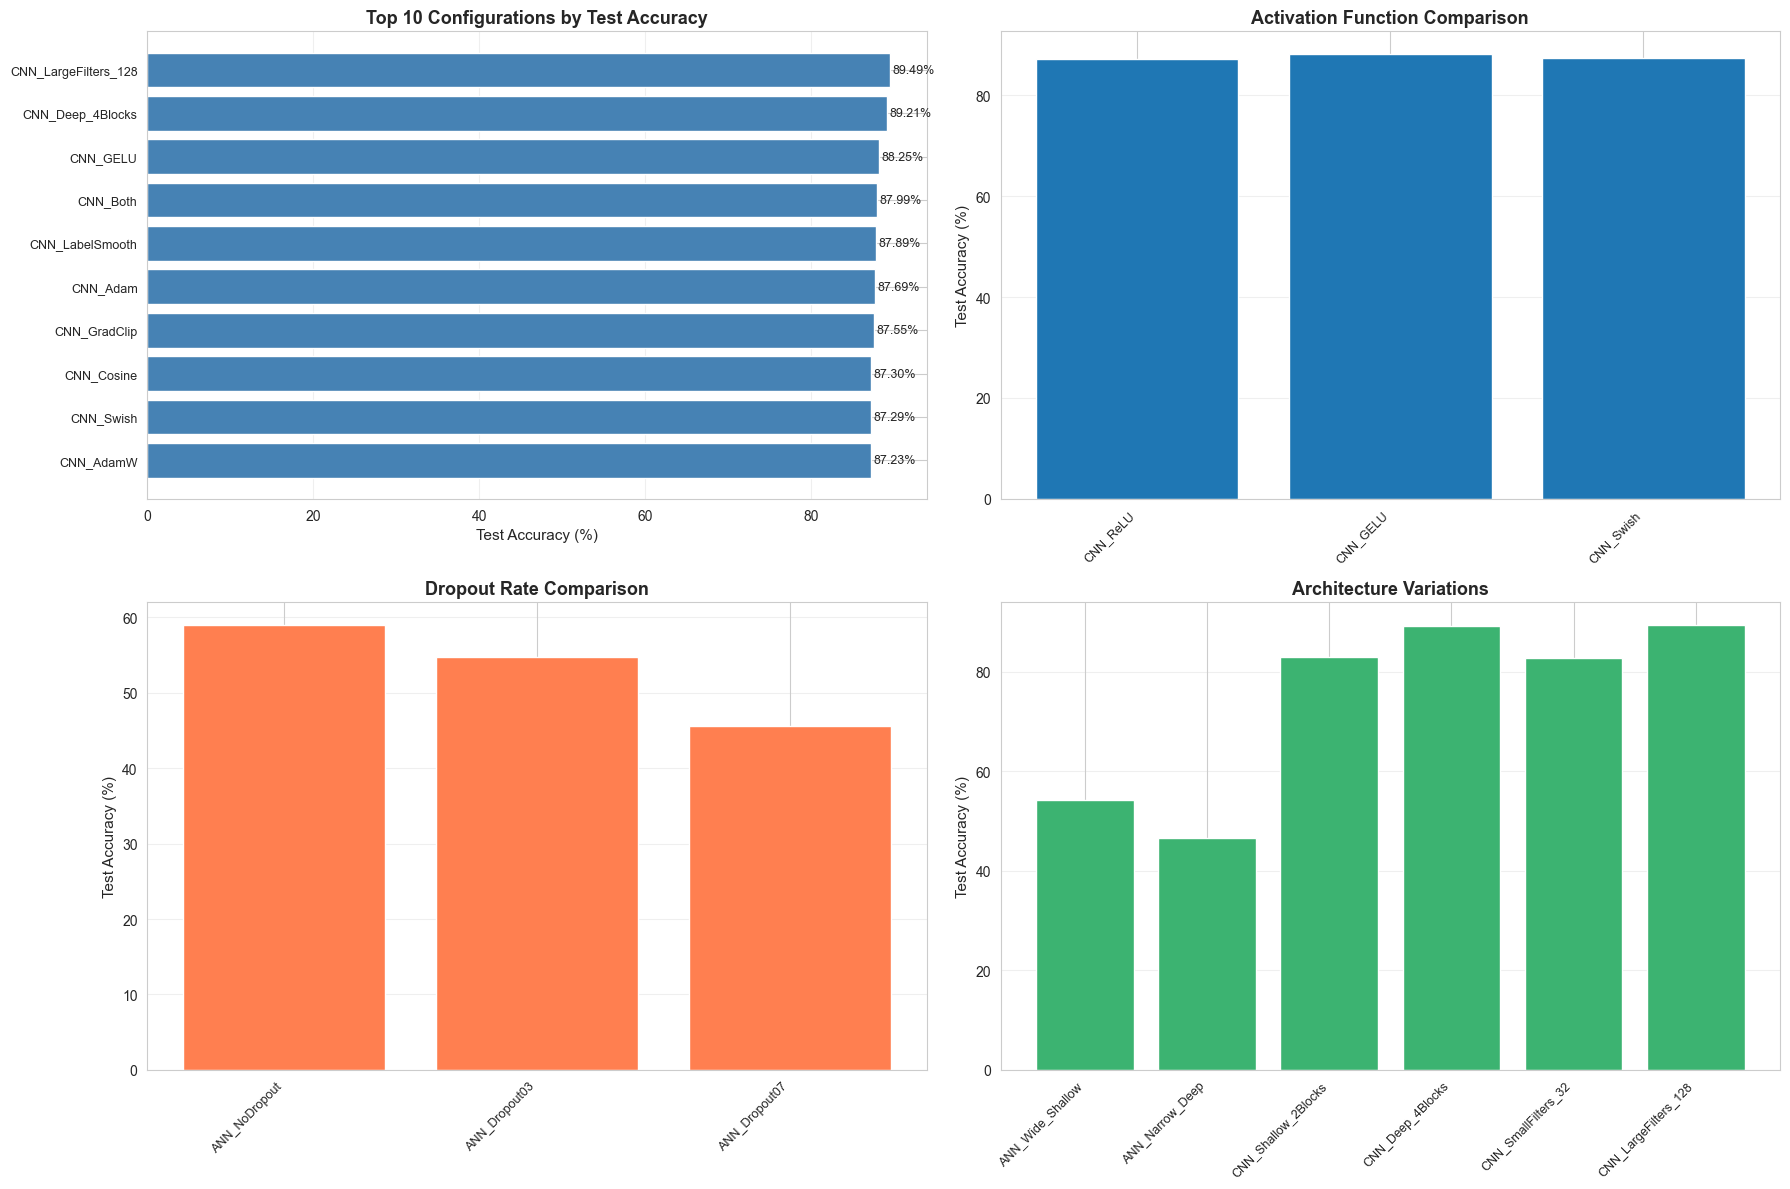

✓ Saved ablation visualization to 'ablation_analysis.png'

KEY ABLATION INSIGHTS

Best Configuration: CNN_LargeFilters_128
   Test Accuracy: 0.8949
   Description: CNN with larger filters (128 base)

Worst Configuration: ANN_NoBatchNorm
   Test Accuracy: 0.4434
   Description: ANN without BatchNorm (harder to train)

Accuracy Range: 44.34% - 89.49%
   Performance Spread: 45.15 percentage points



In [31]:
# Visualize ablation results
if len(ablation_results) > 0:
    ablation_df = pd.DataFrame(ablation_results)
    
    # Convert accuracy strings to floats for plotting
    ablation_df['Test_Acc_Float'] = ablation_df['Test Accuracy'].astype(float)
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Plot 1: Top 10 configurations by test accuracy
    top_10 = ablation_df.nlargest(10, 'Test_Acc_Float')
    axes[0, 0].barh(range(len(top_10)), top_10['Test_Acc_Float'] * 100, color='steelblue')
    axes[0, 0].set_yticks(range(len(top_10)))
    axes[0, 0].set_yticklabels(top_10['Configuration'], fontsize=9)
    axes[0, 0].set_xlabel('Test Accuracy (%)', fontsize=11)
    axes[0, 0].set_title('Top 10 Configurations by Test Accuracy', fontsize=13, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3, axis='x')
    axes[0, 0].invert_yaxis()
    
    # Add value labels
    for i, v in enumerate(top_10['Test_Acc_Float'] * 100):
        axes[0, 0].text(v + 0.3, i, f'{v:.2f}%', va='center', fontsize=9)
    
    # Plot 2: Activation function comparison
    activation_configs = ablation_df[ablation_df['Configuration'].str.contains('ReLU|GELU|Swish')]
    if len(activation_configs) > 0:
        axes[0, 1].bar(range(len(activation_configs)), activation_configs['Test_Acc_Float'] * 100)
        axes[0, 1].set_xticks(range(len(activation_configs)))
        axes[0, 1].set_xticklabels(activation_configs['Configuration'], rotation=45, ha='right', fontsize=9)
        axes[0, 1].set_ylabel('Test Accuracy (%)', fontsize=11)
        axes[0, 1].set_title('Activation Function Comparison', fontsize=13, fontweight='bold')
        axes[0, 1].grid(True, alpha=0.3, axis='y')
    else:
        axes[0, 1].text(0.5, 0.5, 'No activation ablation data', ha='center', va='center')
        axes[0, 1].set_title('Activation Function Comparison', fontsize=13, fontweight='bold')
    
    # Plot 3: Dropout comparison
    dropout_configs = ablation_df[ablation_df['Configuration'].str.contains('Dropout')]
    if len(dropout_configs) > 0:
        axes[1, 0].bar(range(len(dropout_configs)), dropout_configs['Test_Acc_Float'] * 100, color='coral')
        axes[1, 0].set_xticks(range(len(dropout_configs)))
        axes[1, 0].set_xticklabels(dropout_configs['Configuration'], rotation=45, ha='right', fontsize=9)
        axes[1, 0].set_ylabel('Test Accuracy (%)', fontsize=11)
        axes[1, 0].set_title('Dropout Rate Comparison', fontsize=13, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3, axis='y')
    else:
        axes[1, 0].text(0.5, 0.5, 'No dropout ablation data', ha='center', va='center')
        axes[1, 0].set_title('Dropout Rate Comparison', fontsize=13, fontweight='bold')
    
    # Plot 4: Architecture variations
    arch_configs = ablation_df[ablation_df['Configuration'].str.contains('Wide|Narrow|Shallow|Deep|Filters|Blocks')]
    if len(arch_configs) > 0 and len(arch_configs) <= 10:
        axes[1, 1].bar(range(len(arch_configs)), arch_configs['Test_Acc_Float'] * 100, color='mediumseagreen')
        axes[1, 1].set_xticks(range(len(arch_configs)))
        axes[1, 1].set_xticklabels(arch_configs['Configuration'], rotation=45, ha='right', fontsize=9)
        axes[1, 1].set_ylabel('Test Accuracy (%)', fontsize=11)
        axes[1, 1].set_title('Architecture Variations', fontsize=13, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
    else:
        axes[1, 1].text(0.5, 0.5, f'Too many configs ({len(arch_configs)}) or no data', ha='center', va='center')
        axes[1, 1].set_title('Architecture Variations', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('ablation_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ Saved ablation visualization to 'ablation_analysis.png'")
    
    # Print key insights
    print("\n" + "="*100)
    print("KEY ABLATION INSIGHTS")
    print("="*100)
    
    best_config = ablation_df.loc[ablation_df['Test_Acc_Float'].idxmax()]
    worst_config = ablation_df.loc[ablation_df['Test_Acc_Float'].idxmin()]
    
    print(f"\nBest Configuration: {best_config['Configuration']}")
    print(f"   Test Accuracy: {best_config['Test Accuracy']}")
    print(f"   Description: {best_config['Description']}")
    
    print(f"\nWorst Configuration: {worst_config['Configuration']}")
    print(f"   Test Accuracy: {worst_config['Test Accuracy']}")
    print(f"   Description: {worst_config['Description']}")
    
    # FIXED: Use 'Test_Acc_Float' (with underscore) instead of 'Test Acc_Float' (with space)
    print(f"\nAccuracy Range: {worst_config['Test_Acc_Float']*100:.2f}% - {best_config['Test_Acc_Float']*100:.2f}%")
    print(f"   Performance Spread: {(best_config['Test_Acc_Float'] - worst_config['Test_Acc_Float'])*100:.2f} percentage points")
    
    print("\n" + "="*100)
else:
    print("No ablation results to visualize. Run ablation experiments first.")

## 7. Results & Discussion

### 7.1 Model Comparison

In [32]:
# Create comparison table
ann_params, _ = count_parameters(ann_trained)
cnn_params, _ = count_parameters(cnn_trained)
hybrid_params, _ = count_parameters(hybrid_trained)

comparison_data = {
    'Model': ['ANN', 'CNN', 'Hybrid'],
    'Test Accuracy': [f"{ann_acc:.4f}", f"{cnn_acc:.4f}", f"{hybrid_acc:.4f}"],
    'Test Acc %': [f"{ann_acc*100:.2f}%", f"{cnn_acc*100:.2f}%", f"{hybrid_acc*100:.2f}%"],
    'Parameters': [f"{ann_params:,}", f"{cnn_params:,}", f"{hybrid_params:,}"],
    'Training Time': [f"{ann_time/60:.2f} min", f"{cnn_time/60:.2f} min", f"{hybrid_time/60:.2f} min"],
    'Best Val Acc': [f"{max(ann_history['val_acc']):.4f}", 
                     f"{max(cnn_history['val_acc']):.4f}", 
                     f"{max(hybrid_history['val_acc']):.4f}"]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*100)
print("FINAL MODEL COMPARISON")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

# Save comparison
comparison_df.to_csv('model_comparison.csv', index=False)
print("\nSaved model comparison to 'model_comparison.csv'")


FINAL MODEL COMPARISON
 Model Test Accuracy Test Acc % Parameters Training Time Best Val Acc
   ANN        0.5593     55.93%  9,058,058     30.29 min       0.5656
   CNN        0.9084     90.84%  3,251,018     39.13 min       0.9144
Hybrid        0.9113     91.13%  3,380,298     39.19 min       0.9184

Saved model comparison to 'model_comparison.csv'


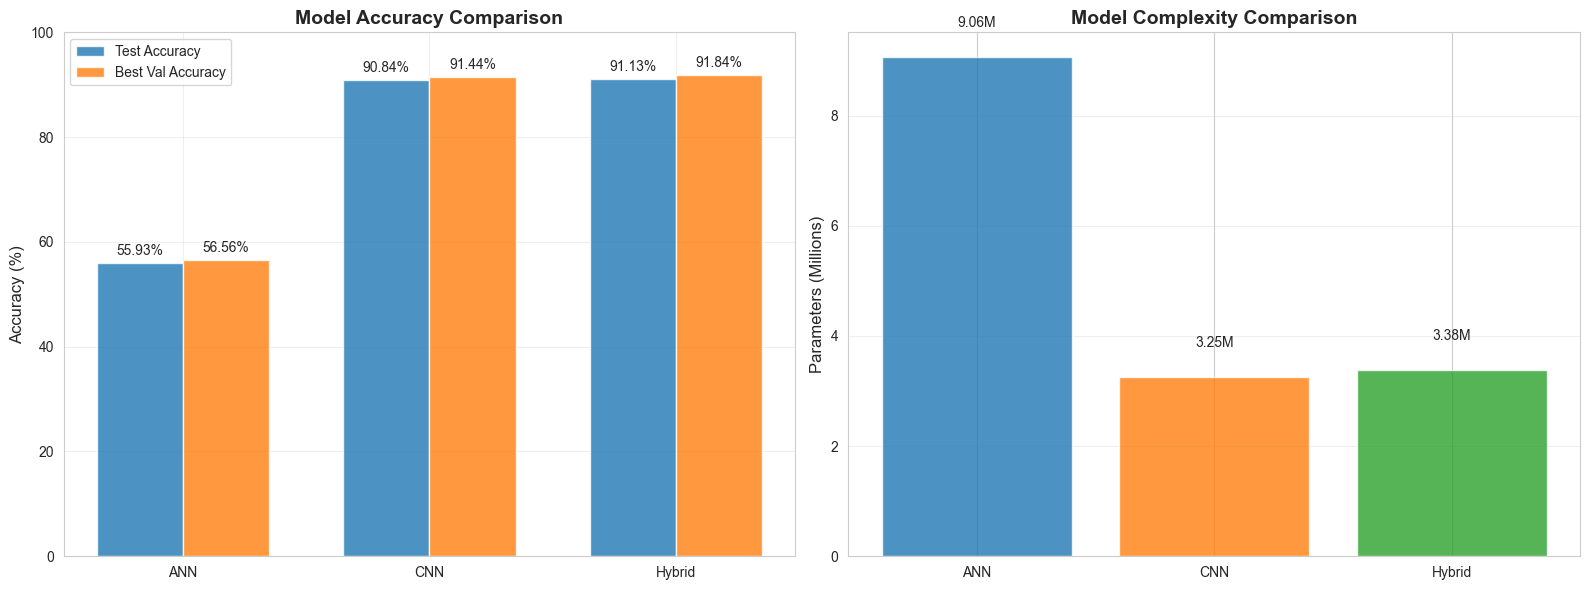

Saved comparison visualization to 'model_comparison.png'


In [33]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
models = ['ANN', 'CNN', 'Hybrid']
test_accs = [ann_acc * 100, cnn_acc * 100, hybrid_acc * 100]
val_accs = [max(ann_history['val_acc']) * 100, 
            max(cnn_history['val_acc']) * 100,
            max(hybrid_history['val_acc']) * 100]

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, test_accs, width, label='Test Accuracy', alpha=0.8)
axes[0].bar(x + width/2, val_accs, width, label='Best Val Accuracy', alpha=0.8)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 100])

# Add value labels on bars
for i, v in enumerate(test_accs):
    axes[0].text(i - width/2, v + 1, f'{v:.2f}%', ha='center', va='bottom', fontsize=10)
for i, v in enumerate(val_accs):
    axes[0].text(i + width/2, v + 1, f'{v:.2f}%', ha='center', va='bottom', fontsize=10)

# Parameter count comparison
params = [ann_params / 1e6, cnn_params / 1e6, hybrid_params / 1e6]
axes[1].bar(models, params, alpha=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('Parameters (Millions)', fontsize=12)
axes[1].set_title('Model Complexity Comparison', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(params):
    axes[1].text(i, v + 0.5, f'{v:.2f}M', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved comparison visualization to 'model_comparison.png'")

## 8. Final Evaluation

This cell loads the best saved checkpoints and evaluates all three models on the test set.

In [ ]:
print("\n" + "="*100)
print("FINAL EVALUATION - LOADING BEST CHECKPOINTS")
print("="*100)

# Load best model checkpoints
print("\n1. Loading ANN model...")
ann_final = ANN(hidden_dims=[2048, 1024, 512, 256], dropout_rate=0.5, 
                activation='relu', use_batchnorm=True).to(device)
ann_final.load_state_dict(torch.load('checkpoints/ANN_best.pth'))
ann_final_acc, ann_final_preds, ann_final_labels = evaluate_model(ann_final, test_loader, device)
print(f"   ANN Test Accuracy: {ann_final_acc:.4f} ({ann_final_acc*100:.2f}%)")

print("\n2. Loading CNN model...")
cnn_final = CNN(base_filters=64, num_blocks=3, dropout_rate=0.5, activation='relu').to(device)
cnn_final.load_state_dict(torch.load('checkpoints/CNN_best.pth'))
cnn_final_acc, cnn_final_preds, cnn_final_labels = evaluate_model(cnn_final, test_loader, device)
print(f"   CNN Test Accuracy: {cnn_final_acc:.4f} ({cnn_final_acc*100:.2f}%)")

print("\n3. Loading Hybrid model...")
hybrid_final = HybridCNNANN(cnn_filters=[64, 128, 256], ann_hidden_dims=[512, 256], 
                             dropout_rate=0.5, activation='relu').to(device)
hybrid_final.load_state_dict(torch.load('checkpoints/Hybrid_best.pth'))
hybrid_final_acc, hybrid_final_preds, hybrid_final_labels = evaluate_model(hybrid_final, test_loader, device)
print(f"   Hybrid Test Accuracy: {hybrid_final_acc:.4f} ({hybrid_final_acc*100:.2f}%)")

print("\n" + "="*100)
print("FINAL SUMMARY")
print("="*100)
print(f"{'Model':<15} {'Test Accuracy':<20} {'Status':<15}")
print("-" * 100)
print(f"{'ANN':<15} {f'{ann_final_acc*100:.2f}%':<20} {'✓ Complete':<15}")
print(f"{'CNN':<15} {f'{cnn_final_acc*100:.2f}%':<20} {'✓ Complete':<15}")
print(f"{'Hybrid':<15} {f'{hybrid_final_acc*100:.2f}%':<20} {'✓ Complete':<15}")
print("="*100)

# Determine best model
best_model_name = max(
    [('ANN', ann_final_acc), ('CNN', cnn_final_acc), ('Hybrid', hybrid_final_acc)],
    key=lambda x: x[1]
)[0]
best_acc = max(ann_final_acc, cnn_final_acc, hybrid_final_acc)

print(f"\nBest Model: {best_model_name} with {best_acc*100:.2f}% test accuracy")

if best_acc >= 0.70:
    print("SUCCESS: Target accuracy of ≥70% achieved!")
else:
    print(f"Target accuracy of ≥70% not yet achieved. Current best: {best_acc*100:.2f}%")
    print("Consider: more epochs, different architectures, or hyperparameter tuning")



FINAL EVALUATION - LOADING BEST CHECKPOINTS

1. Loading ANN model...


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

   ANN Test Accuracy: 0.5593 (55.93%)

2. Loading CNN model...


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

   CNN Test Accuracy: 0.9084 (90.84%)

3. Loading Hybrid model...


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

   Hybrid Test Accuracy: 0.9113 (91.13%)

FINAL SUMMARY
Model           Test Accuracy        Status         
----------------------------------------------------------------------------------------------------
ANN             55.93%               ✓ Complete     
CNN             90.84%               ✓ Complete     
Hybrid          91.13%               ✓ Complete     

Best Model: Hybrid with 91.13% test accuracy
SUCCESS: Target accuracy of ≥70% achieved!
